# Zig-Zag Dal Basalt Formation ca. 1382 Ma paleomagnetic pole

## Geologic context

The Zig-Zag Dal Basalt Formation is a thick Mesoproterozoic continental flood-
basalt succession of eastern North Greenland, intruded by the comagmatic
Midsommerso Dolerites (Marcussen & Abrahamsen, 1983). U-Pb baddeleyite on the
dolerites gives 1382 ± 2 Ma (Upton et al., 2005), dating the magmatic event. The
remanence is single-polarity, magnetite-carried.

## Paleomagnetic And Rock Magnetic Data

This notebook recreates the Zig-Zag Dal Basalt pole at the site level from the
19 sites of Marcussen & Abrahamsen (1983).

## Age Constraints
- U-Pb dating of two baddeleyite multi-grain fraction upper intercept ages from one intrusive Midsommersø Dolerites yields an age of 1382 ± 2 Ma (Upton et al., 2005)

## References

- Paleomagnetic source: Marcussen, C., & Abrahamsen, N. (1983). Palaeomagnetism of the proterozoic zig-zag dal basalt and the midsommersø dolerites, eastern north greenland. Geophysical Journal International, 73(2), 367–387. https://doi.org/10.1111/j.1365-246X.1983.tb03321.x

- Geochronology / age-constraint note (compilation): U-Pb dating of baddeleyite from intrusive Midsommersø Dolerites yields an age of 1382 ± 2 Ma (Upton et al., 2005); Upton, B. G. J., Rämö, O. T., Heaman, L. M., Blichert-Toft, J., Kalsbeek, F., Barry, T. L., & Jepsen, H. F. (2005). The Mesoproterozoic Zig-Zag Dal basalts and associated intrusions of eastern North Greenland: Mantle plume–lithosphere interaction. Contributions to Mineralogy and Petrology, 149(1), 40–56. https://doi.org/10.1007/s00410-004-0634-7
- Marcussen, C., & Abrahamsen, N. (1983). Palaeomagnetism of the proterozoic zig-zag dal basalt and the midsommersø dolerites, eastern north greenland. Geophysical Journal International, 73(2), 367–387. https://doi.org/10.1111/j.1365-246X.1983.tb03321.x

In [1]:
import pole_tools as pt
import pmagpy.ipmag as ipmag
import pmagpy.pmag as pmag
import pandas as pd
import matplotlib.pyplot as plt

%config InlineBackend.figure_format='retina'
%matplotlib inline

## Site-level data

Site means are loaded from `../data/1382_ZigZag_Dal_Basalt/` (the bedding-
corrected directions of Marcussen & Abrahamsen, 1983).

In [2]:
sites_geo, sites_tc = pt.load_magic_sites('../data/1382_ZigZag_Dal_Basalt/sites.txt')
sub = sites_tc if len(sites_tc) else sites_geo
study_lat, study_lon = 81.2, 334.8
print(f'{len(sub)} sites (bedding-corrected)')
sub[['site', 'lat', 'lon', 'dir_dec', 'dir_inc', 'dir_alpha95', 'dir_k', 'dir_n_samples', 'vgp_lat', 'vgp_lon']]

19 sites (bedding-corrected)


,site,lat,lon,dir_dec,dir_inc,dir_alpha95,dir_k,dir_n_samples,vgp_lat,vgp_lon
0,BA-01,81.2,334.8,91.2,-14.3,1.8,801,9,-7.3,64.8
1,BA-02,81.2,334.8,92.4,-15.0,2.4,461,9,-7.9,63.8
2,BA-03,81.2,334.8,94.1,-23.8,2.3,419,9,-12.9,62.8
3,BA-04,81.2,334.8,91.7,-24.0,2.0,677,9,-12.6,65.2
4,BA-05,81.2,334.8,93.9,-22.8,2.2,496,10,-12.3,63.0
5,BA-06,81.2,334.8,87.5,-19.7,11.1,38,6,-9.6,69.0
6,BA-09,81.2,334.8,97.0,-6.4,3.0,298,9,-4.2,58.6
7,BA-10,81.2,334.8,102.7,-9.7,3.1,327,8,-6.7,53.2
8,BA-11,81.2,334.8,97.7,-25.8,0.8,4037,9,-14.5,59.5
9,BA-14,81.2,334.8,90.4,-15.2,20.4,12,6,-7.7,65.4


Plon: 242.8  Plat: 12.2
Number of directions in mean (n): 19
Angular radius of 95% confidence (A_95): 3.9
Precision parameter (k) estimate: 75.5

prior compilation (GPMDB 98): 12.2 N / 242.8 E, N=19


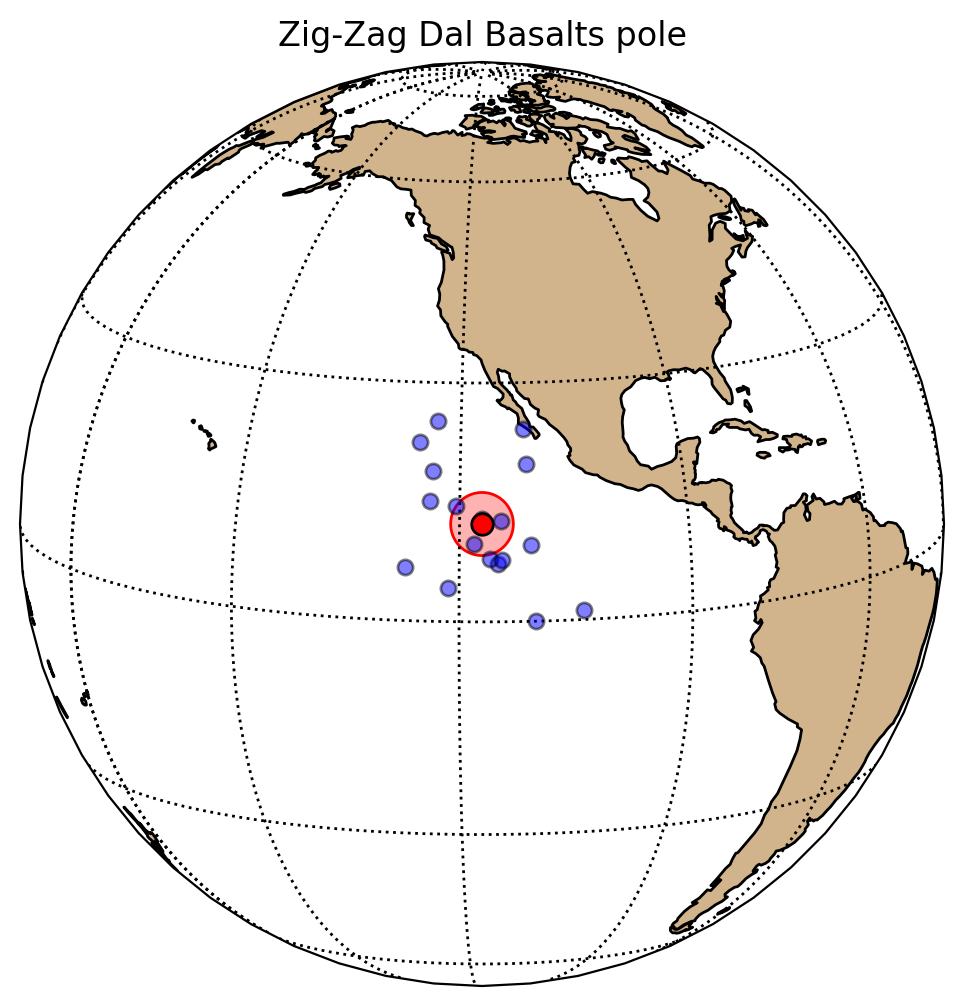

In [3]:
# the VGPs are southern in the student convention; report at the positive-latitude
# antipode to match the prior compilation (GPMDB 98)
vgp_block, pm = pt.compute_mean_pole(sub, unify_polarity=True)
if pm['inc'] < 0:
    vgp_block, pm = pt.compute_mean_pole(sub, unify_polarity=True, flip=True)
pole_mean = pm
ipmag.print_pole_mean(pole_mean)
print('\nprior compilation (GPMDB 98): 12.2 N / 242.8 E, N=19')
_ = pt.plot_vgps_and_pole(vgp_block, pole_mean, central_longitude=pole_mean['dec'],
                          central_latitude=pole_mean['inc'], figsize=(6, 6))
plt.title('Zig-Zag Dal Basalts pole')
plt.show()

Dec: 273.6  Inc: 22.0
Number of directions in mean (n): 19
Angular radius of 95% confidence (a_95): 5.6
Precision parameter (k) estimate: 37.0


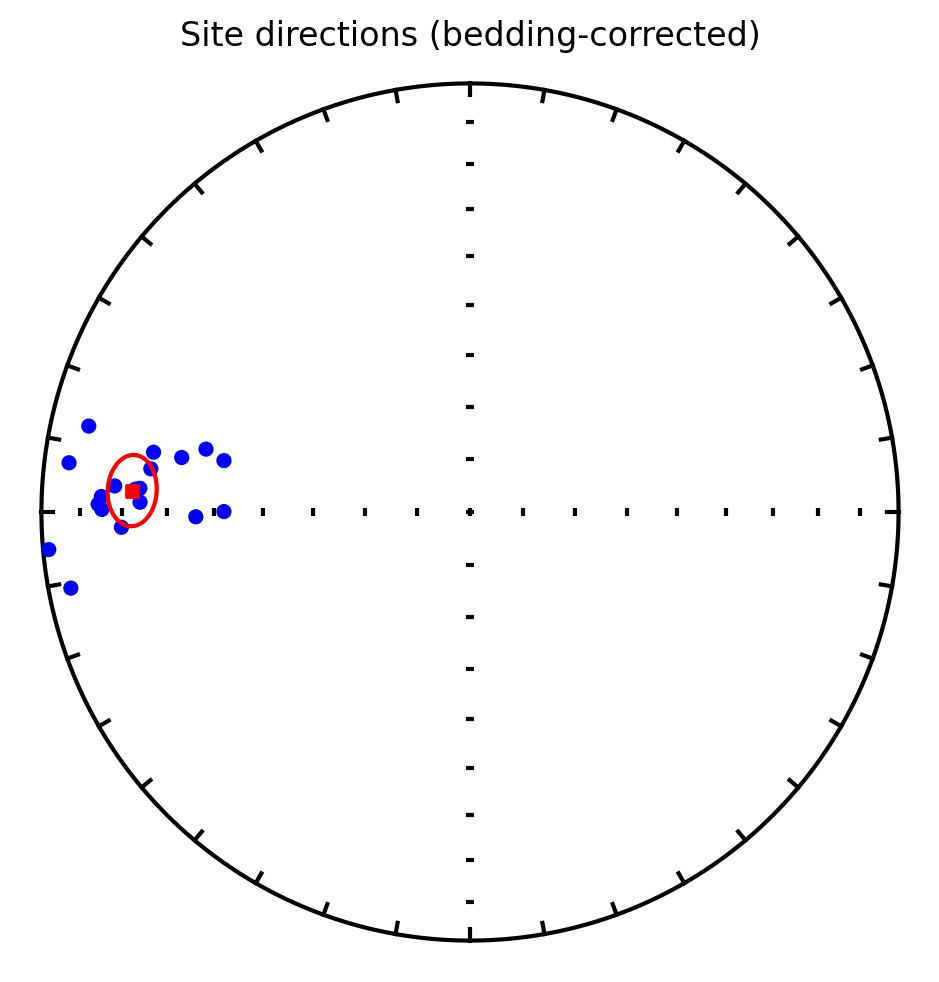

In [4]:
dir_block, dir_mean = pt.compute_mean_direction(sub, unify_polarity=True)
ipmag.print_direction_mean(dir_mean)
ipmag.plot_net()
ipmag.plot_di(di_block=dir_block, color='blue', marker='o')
ipmag.plot_di_mean(dir_mean['dec'], dir_mean['inc'], dir_mean['alpha95'], color='red', marker='s')
plt.title('Site directions (bedding-corrected)')
plt.show()

## Paleosecular variation

The VGPs are over-concentrated (K > 70), so the Deenen et al. (2011) test flags
under-sampling of paleosecular variation — consistent with the prior compilation
scoring R2 = 0.

A_95 of 3.9 passes Deenen et al. (2011) criteria of being between 3.7 and 12.8 for this number of sites


<AxesSubplot:title={'center':'Deenen et al. (2011) test'}, xlabel='Number of sites (N)', ylabel='$A_{95}$ (°)'>

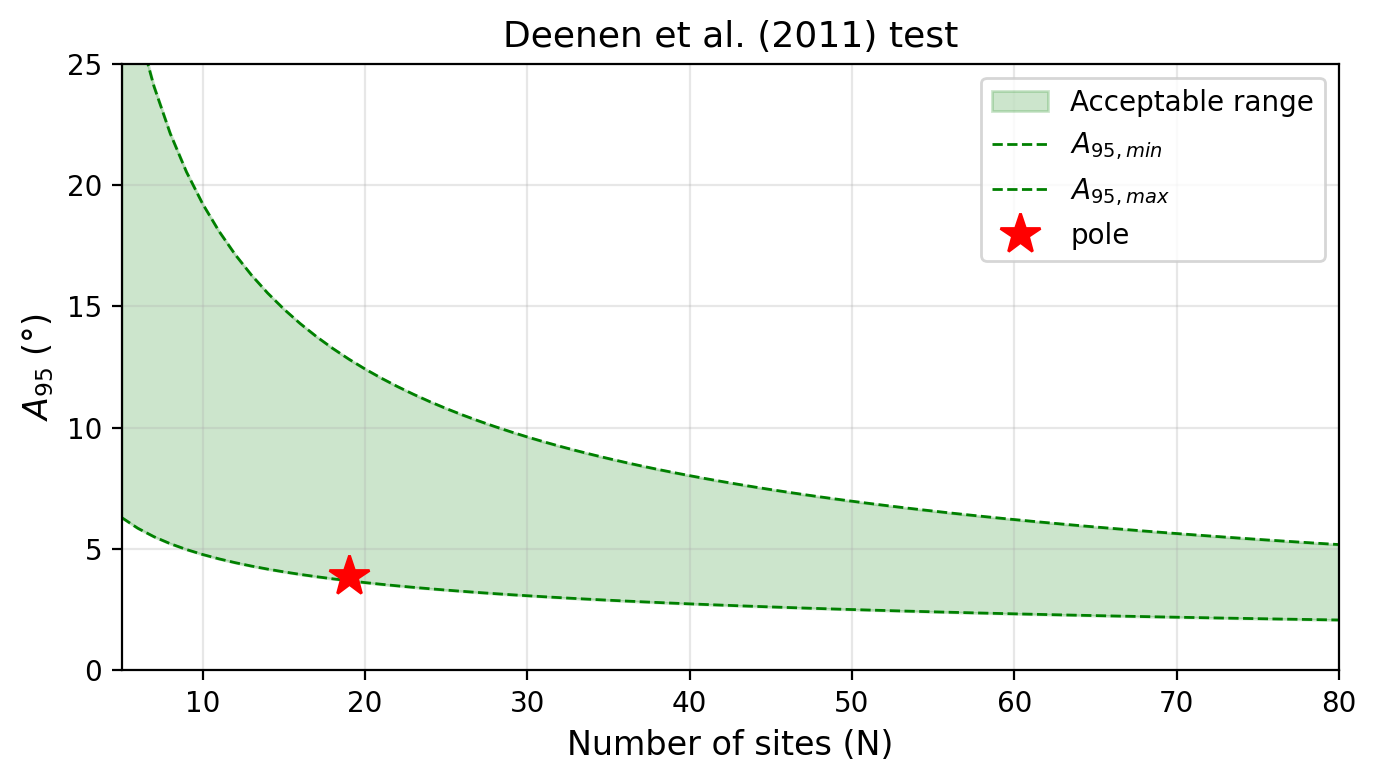

In [5]:
pt.Deenen_test(pole_mean['n'], pole_mean['alpha95'])
pt.plot_Deenen_test(pole_mean)

posx and posy should be finite values
posx and posy should be finite values


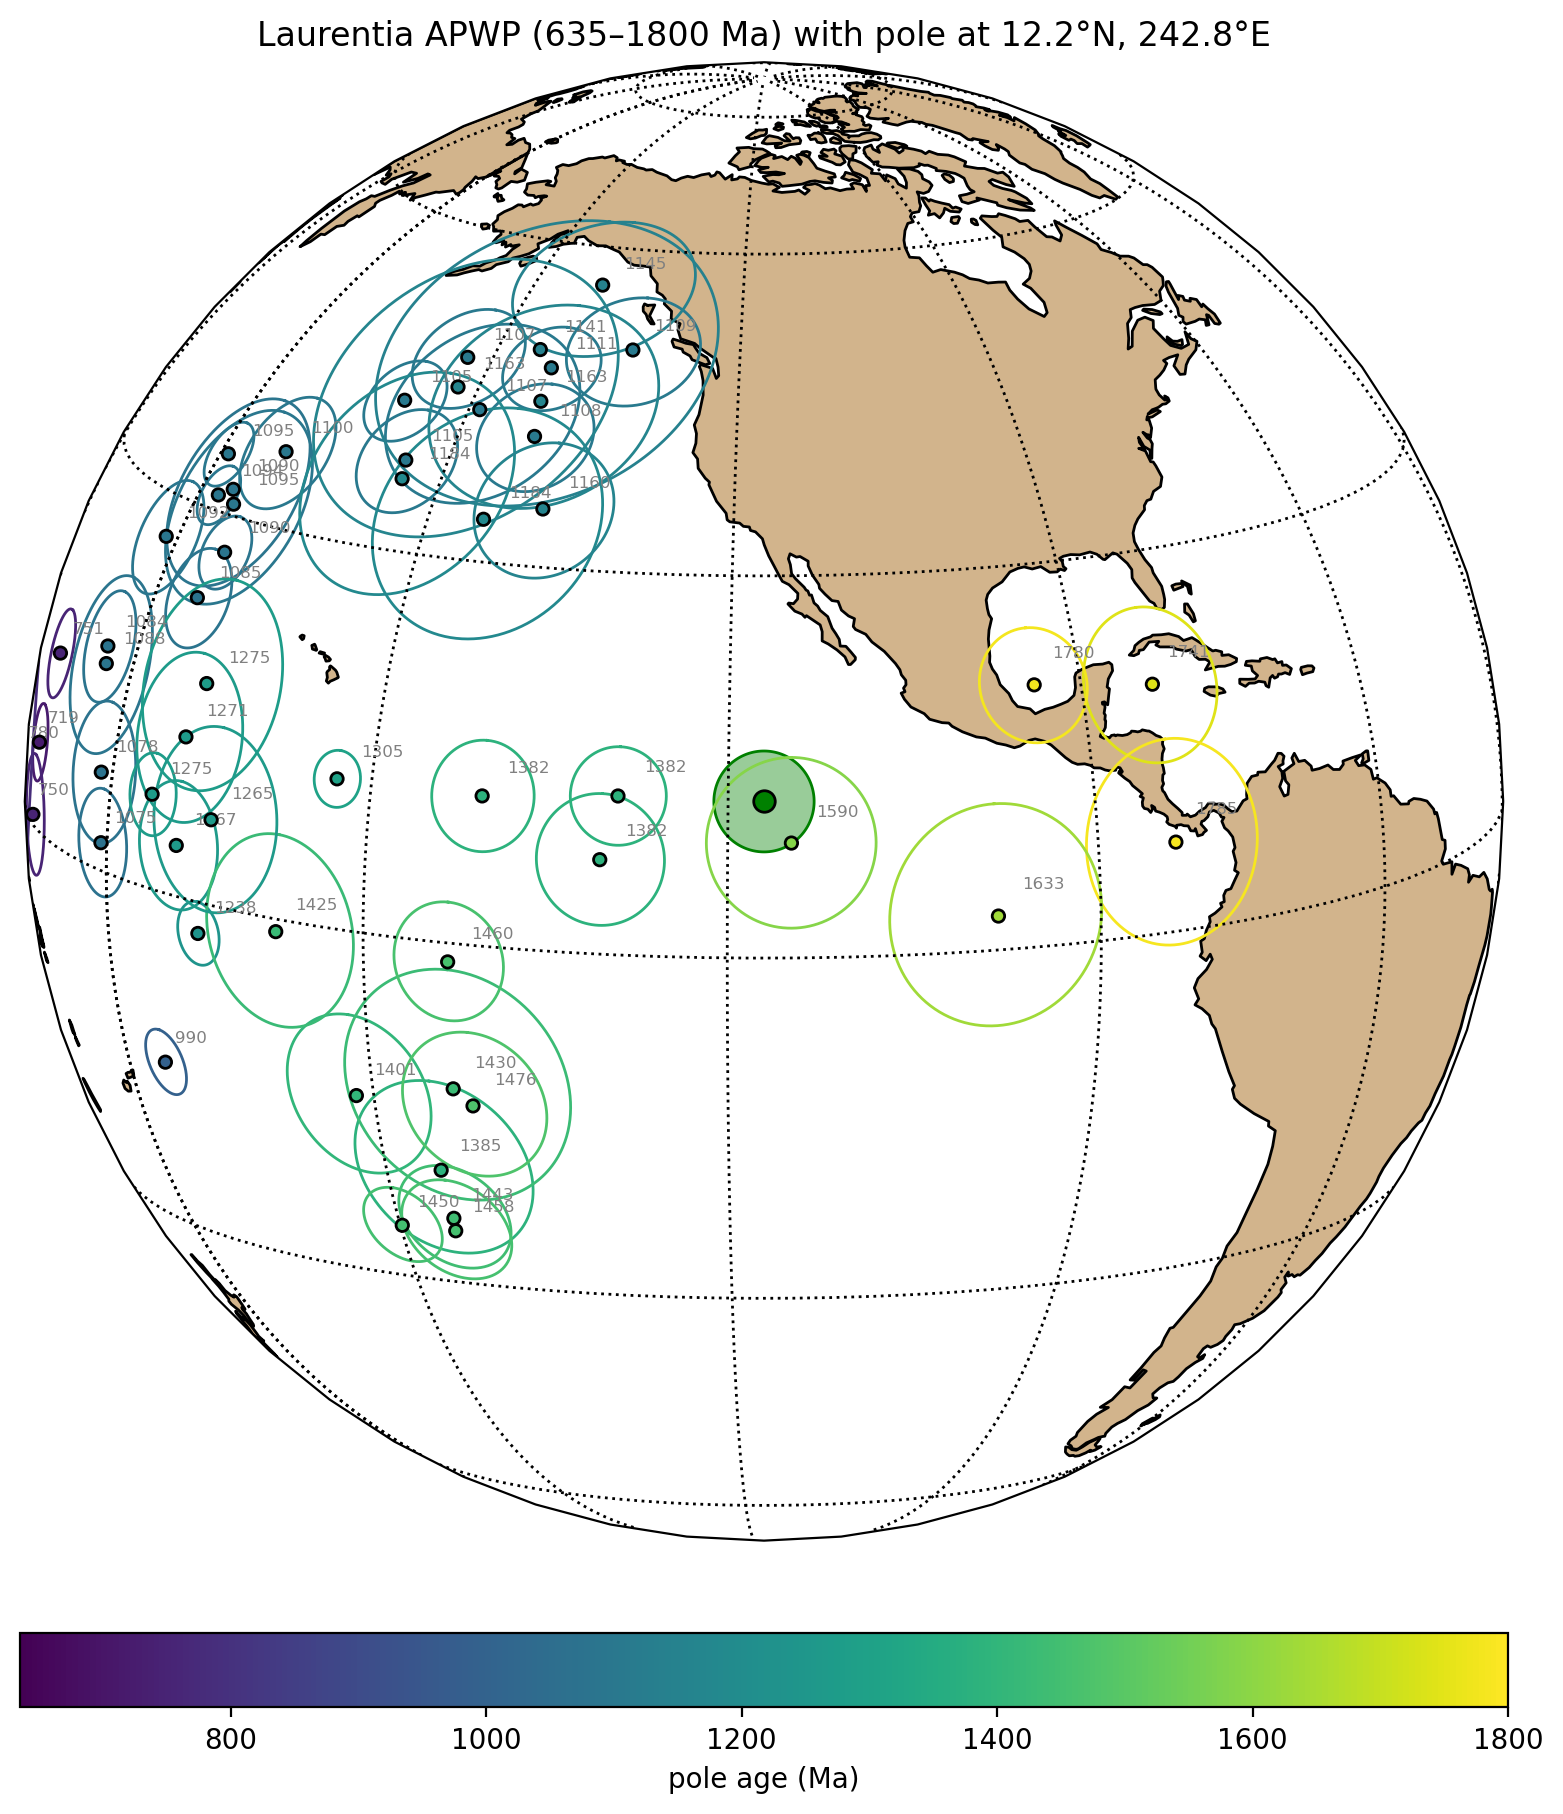

In [6]:
Laurentia_poles = pt.get_Laurentia_poles()
ax = pt.plot_apwp_context(Laurentia_poles, pole_mean['inc'], pole_mean['dec'],
                          pole_mean['alpha95'], age_min=635, age_max=1800,
                          projection='orthographic',
                          central_longitude=pole_mean['dec'],
                          central_latitude=pole_mean['inc'])
plt.show()

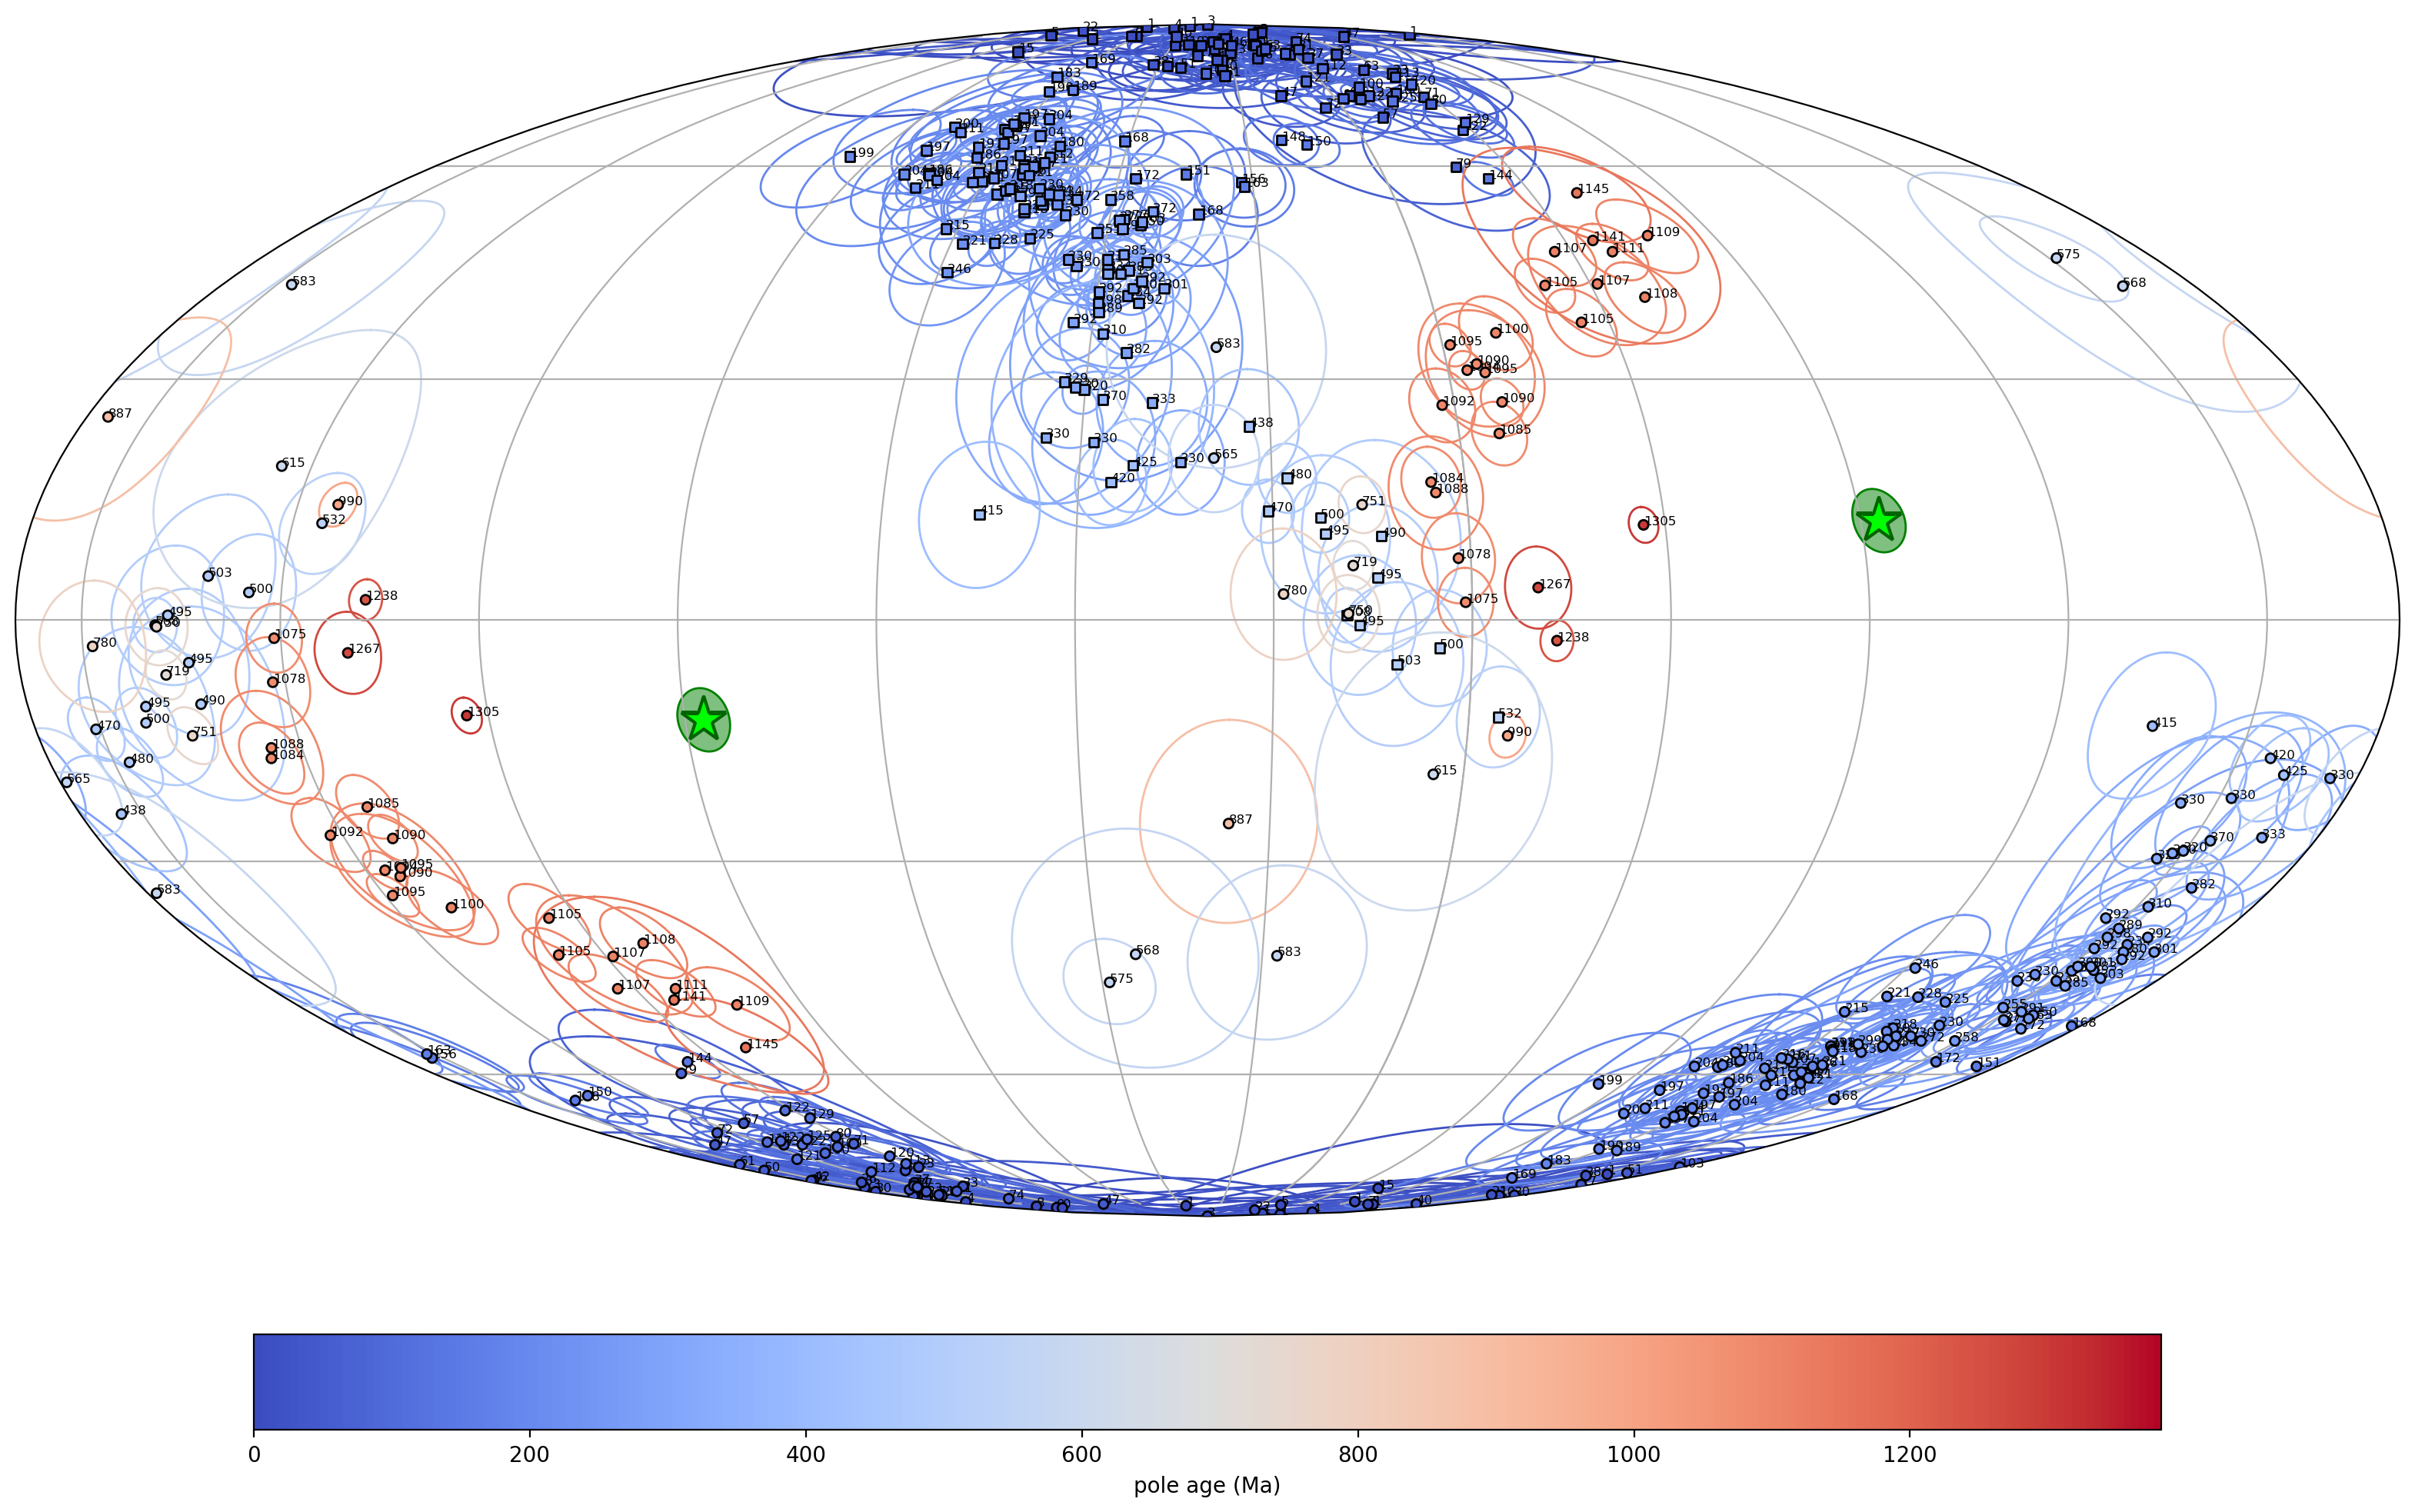

<GeoAxesSubplot:>

In [7]:
Laurentia_stricto_poles = pt.get_Laurentia_stricto_poles()
pt.plot_pole_overlap('Zig-Zag Dal Basalts', Laurentia_stricto_poles, pt.Torsvik2012_Laurentia,
                     pole_plat=pole_mean['inc'], pole_plon=pole_mean['dec'],
                     pole_A95=pole_mean['alpha95'], pole_age=1382)

## Paleosecular variation and VGP-shape diagnostics

The Fisher-quantile (fishqq) test assesses whether the site VGPs are drawn from a
Fisher distribution, and the shape-elongation/inclination (SVEI) test compares the
VGP-scatter elongation against the TK03.GAD paleosecular-variation model expectation
at the sampling paleolatitude.

{'Mode': 'Mode 1',
 'Dec': 242.83208592094178,
 'Inc': 12.233475761775836,
 'N': 19,
 'Mu': 0.8072871025163716,
 'Mu_critical': 1.207,
 'Me': 0.7239295638446457,
 'Me_critical': 1.094,
 'Test_result': 'Consistent with Fisher distribution'}

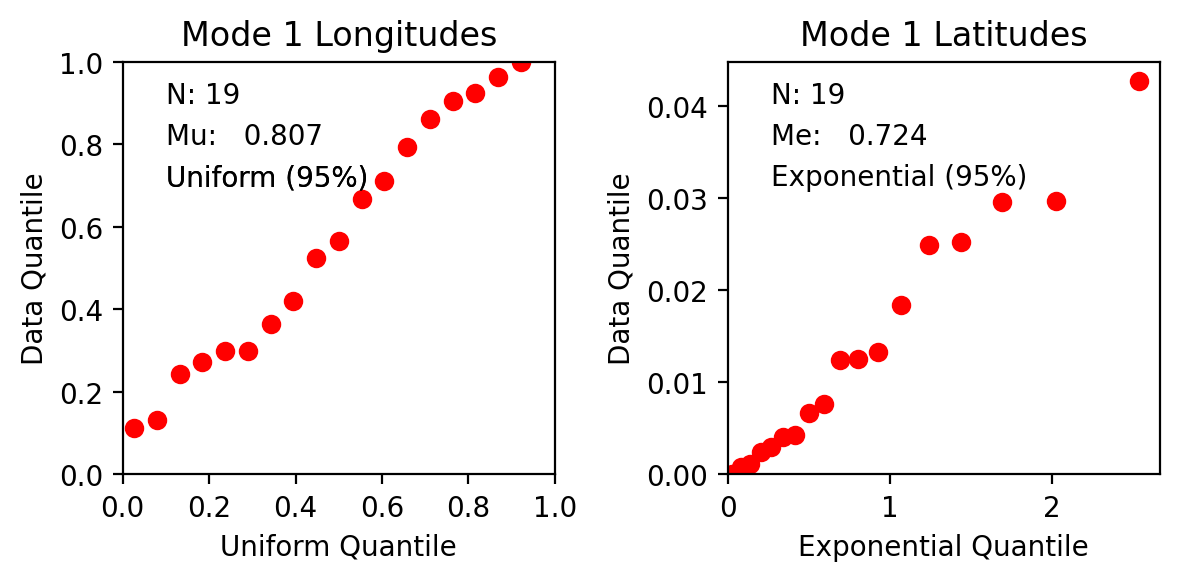

In [8]:
fishqq_result = pt.fishqq_vgps(sub, unify_polarity=True)
fishqq_result

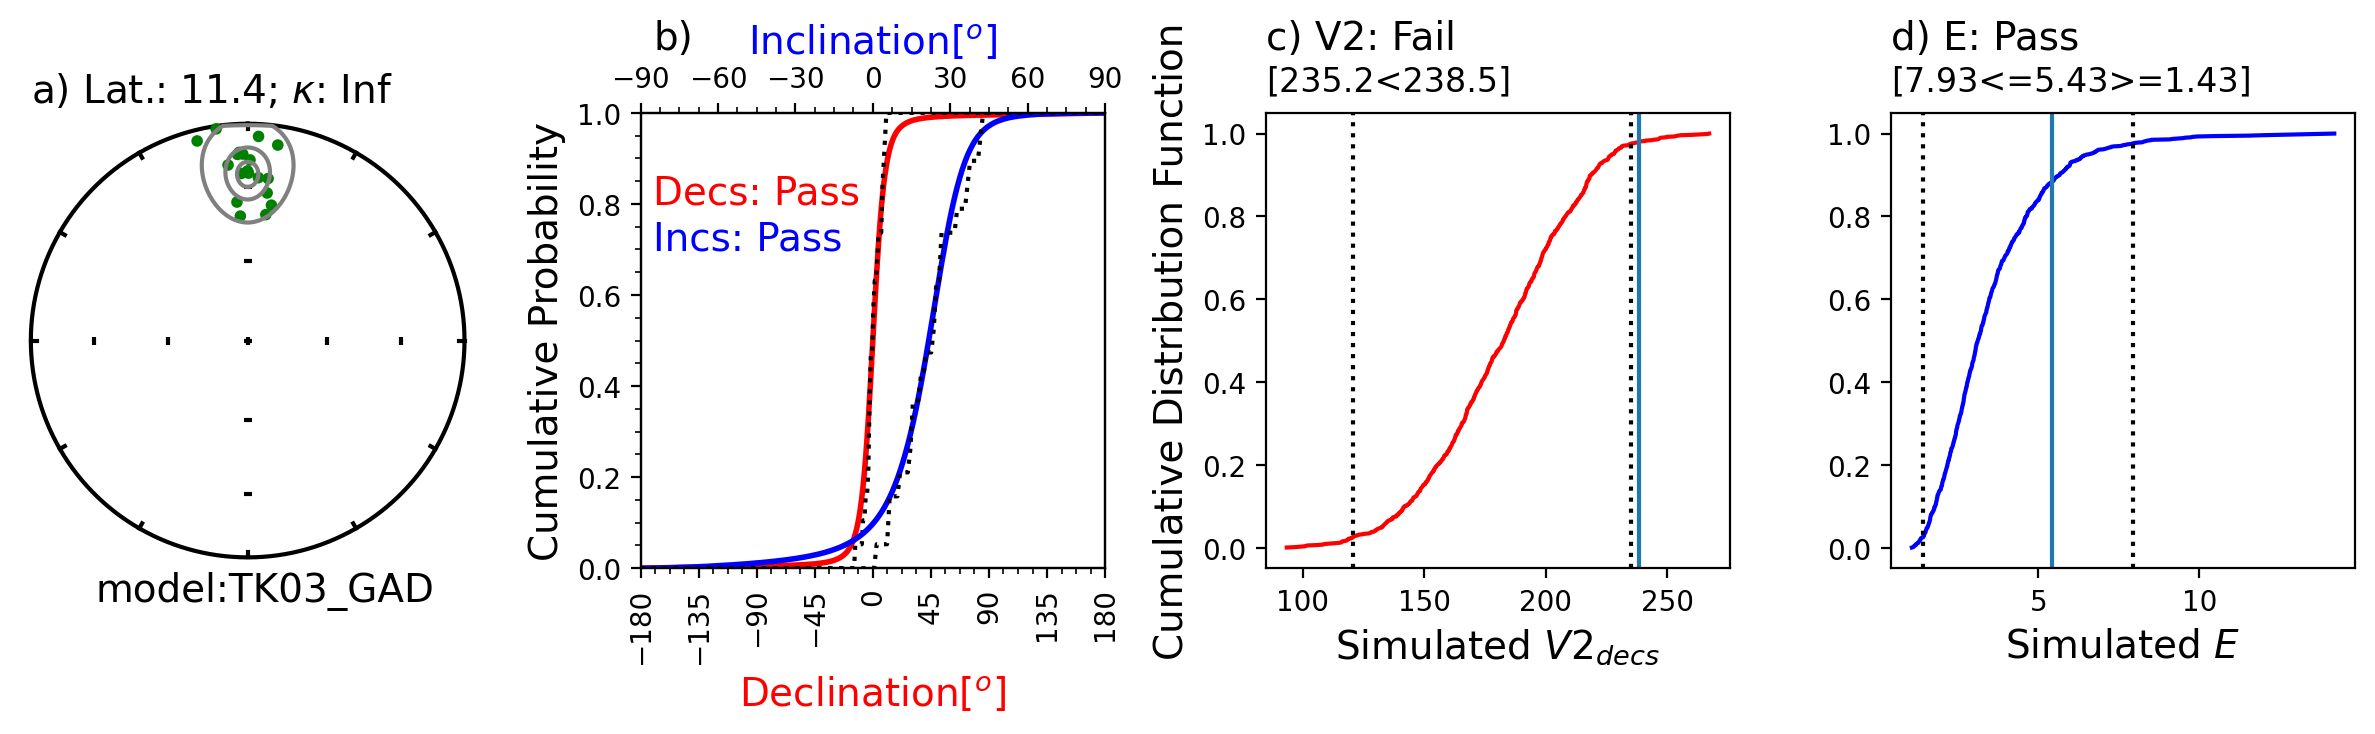

paleolatitude = 11.4 deg; elongation E = 5.43 (consistent with TK03.GAD)


In [9]:
_slat, _slon = float(sub['lat'].mean()), float(sub['lon'].mean())
try:
    svei_result = pt.svei_test_vgps(sub, _slon, _slat, model='TK03_GAD', plot=True)
except TypeError:
    svei_result = pt.svei_test_vgps(sub, _slon, _slat, model='TK03_GAD', plot=False)
    print('(SVEI elongation plot skipped: E below the TK03.GAD model minimum)')
print(f"paleolatitude = {svei_result['lat']:.1f} deg; elongation E = {svei_result['E']:.2f} "
      f"({'consistent' if svei_result['E_result'] else 'inconsistent'} with TK03.GAD)")

## R-score summary (Meert et al., 2020)

| R | Criterion | Score | Justification |
|---|---|---|---|
| 1 | Age within ± 15 Ma | **1** | U-Pb baddeleyite 1382 ± 2 Ma on the intrusive Midsommerso Dolerites (Upton et al., 2005). |
| 2 | Techniques and statistical analysis | **0** | AF demagnetization; the VGPs are over-concentrated (K > 70, A95 below the Deenen et al. (2011) lower bound), indicating under-averaged paleosecular variation. |
| 3 | Magnetic mineralogy characterized | **1** | Magnetite remanence (Marcussen & Abrahamsen, 1983). |
| 4 | Field tests constrain age of magnetization | **0** | No baked-contact or fold test. |
| 5 | Structural control / tectonic coherence | **1** | Autochthonous eastern North Greenland (Laurentia-Greenland); bedding-corrected. |
| 6 | Presence of reversals | **0** | Single polarity. |
| 7 | No resemblance to younger poles | **1** | Distinct from younger Laurentia poles. |
| | Total | **4/7** | Grade B |

### Characteristic remanent magnetization pole

| | This study (site VGPs) | Marcussen & Abrahamsen (1983) | Previous Nordic compilation |
|---|---|---|---|
| Component | Characteristic remanent magnetization | Stable remanence (AF-cleaned) | Zig-Zag Dal Basalts |
| N (sites) | 19 | 19 (24) | 19 |
| N (specimens) | 135 | 135 | 135 |
| Dec (°) | 273.6 | 93.6 | 93.6 |
| Inc (°) | 22.0 | -22.0 | -22.0 |
| k (direction) | 37.0 | 37 | 37.0 |
| α95 (direction, °) | 5.6 | 5.5 | 5.5 |
| Pole lat (°N) | 12.2 | -12.2 | 12.0 |
| Pole lon (°E) | 242.8 | 62.8 | 242.8 |
| A95, pole (°) | 3.9 | 3.8 | 3.8 |
| dp / dm (°) | — | 5.8 / 3.1 | 3.8 / 3.8 |

(Marcussen & Abrahamsen report the pole in the Greenland in-situ frame, −12.2°N/62.8°E; the compilation and this study report its positive-latitude antipode.)

In [10]:
summary = pt.make_nordic_summary(
    terrane='Laurentia-Greenland',
    rockname='Zig-Zag Dal Basalts',
    sites=sub,
    dir_mean=dir_mean,
    pole_mean=pole_mean,
    study_lon=study_lon,
    study_lat=study_lat,
    component_comment='Characteristic remanent magnetization (magnetite); single polarity',
    tests='',
    gpmdb_number='98',
    percent_reversed=0,
    demag_code=3,
    R1=1, R2=0, R3=1, R4='', R5=1, R6=0, R7=1, Grade='B',
    nominal_age=1382, lomagage=1380, himagage=1384,
    REF_method='U-Pb baddeleyite age 1382 +/- 2 Ma on the intrusive Midsommerso Dolerites (Upton et al., 2005); the Zig-Zag Dal Basalts are correlated.',
    POLE_AUTHORS='Marcussen, C., & Abrahamsen, N.',
    YEAR=1983,
    JOURNAL='Geophysical Journal of the Royal Astronomical Society',
    VOLUME='73',
    VPAGES='',
    TITLE='Palaeomagnetism of the Proterozoic Zig-Zag Dal Basalt and the Midsommerso Dolerites, eastern North Greenland',
    COMMENT='Zig-Zag Dal Basalts pole recreated at the site level from Marcussen & Abrahamsen (1983) (audited contribution: dir_tilt_correction set to 100 = bedding-corrected; corrupted Upton 2005 DOI fixed to ...0634-7). Reported at the positive-latitude antipode to match the prior compilation (GPMDB 98; the student computed the southern antipode). Single polarity, over-concentrated VGPs (K>70) -> R2=0; no field test; U-Pb 1382+/-2 Ma -> R1=1. R=4, Grade B.'
)
pt.save_nordic_summary(summary, '1382_ZigZag_Dal_Basalt')
summary

,Terrane,ROCKNAME,RESULT#,COMPONENT,TESTS,TILT,SLAT,SLONG,B,N,...,himagage,REF/method,ROCKNAME,POLE AUTHORS,YEAR,JOURNAL,VOLUME,VPAGES,TITLE,Comment
0,Laurentia-Greenland,Zig-Zag Dal Basalts,GPMDB:98,Characteristic remanent magnetization (magneti...,,100,81.2,334.8,19,135,...,1384,U-Pb baddeleyite age 1382 +/- 2 Ma on the intr...,Zig-Zag Dal Basalts,"Marcussen, C., & Abrahamsen, N.",1983,Geophysical Journal of the Royal Astronomical ...,73,,Palaeomagnetism of the Proterozoic Zig-Zag Dal...,Zig-Zag Dal Basalts pole recreated at the site...
